In [2]:

import sys
import pandas as pd
import torch
import importlib
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from tqdm import tqdm
import logging

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
CHKPT_COPY_DIR = PROJECT_DIR / "checkpoints copy"

sys.path.append(str(PROJECT_DIR))

import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
import datasets.tftg_dataset as tftg_dataset_module
import plotting_utils
import stat_utils

tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

# "mESC": CHKPT_DIR / "tf_dna_mm10_3682785" / "epoch=05-val_auroc=0.9765-val_loss=0.1653.ckpt",

mm10_tf_dna_path = CHKPT_DIR / "tf_dna_mm10_3671604" / "epoch=08-val_auroc=0.9177-val_loss=0.2783.ckpt"
hg38_tf_dna_path = CHKPT_DIR / "tf_dna_hg38_3683606" / "epoch=13-val_auroc=0.9566-val_loss=0.2042.ckpt"

tf_dna_model_checkpoints = {
    "mESC": mm10_tf_dna_path,
    "iPSC": hg38_tf_dna_path,
    "Macrophage": hg38_tf_dna_path,
    "K562": hg38_tf_dna_path
}

# tf_tg_model_checkpoints = {
#     "mESC": {
#         "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3686390" / "epoch=47-val_auroc=0.6560-val_loss=0.6156.ckpt",
#         "E8.5_rep1": CHKPT_DIR / "mESC" / "E8.5_rep1" / "tf_tg_train_E8.5_rep1_3675640" / "epoch=13-val_auroc=0.7088-val_loss=0.6206.ckpt"
#     },
#     "iPSC": {
#         "WT_D13_rep1": CHKPT_DIR / "iPSC" /"WT_D13_rep1" / "tf_tg_train_WT_D13_rep1_3683642" / "epoch=75-val_auroc=0.7784-val_loss=0.5489.ckpt",
#     },
#     "Macrophage": {
#         "buffer_1": CHKPT_DIR / "Macrophage" / "buffer_1" / "tf_tg_train_buffer_1_3685893" / "epoch=152-val_auroc=0.8552-val_loss=0.4733.ckpt",
#         "buffer_2": CHKPT_DIR / "Macrophage" / "buffer_2" / "tf_tg_train_buffer_2_3685903" / "epoch=53-val_auroc=0.7698-val_loss=0.5434.ckpt",
#     }
# }

### Load the latest model checkpoints for each sample

In [13]:
def find_latest_checkpoint(cell_type, sample_name):
    sample_chkpt_dir = CHKPT_DIR / cell_type / sample_name
    
    if not sample_chkpt_dir.exists():
        logging.warning(f"No checkpoints found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
        
    slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_")]
    
    if not slurm_job_dirs:
        logging.warning(f"No checkpoint directories found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    latest_chkpt_dir = max(slurm_job_dirs, key=lambda d: int(d.name.split("_")[-1]))
    slurm_job_id = latest_chkpt_dir.name.split("_")[-1]
    
    chkpt_files = list(latest_chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
    if not chkpt_files:
        logging.warning(f"No checkpoint files found for {sample_name} in {latest_chkpt_dir}")
        return None
    
    latest_chkpt_file = max(chkpt_files, key=lambda f: int(f.stem.split("-")[0].split("=")[1]))
    epoch = latest_chkpt_file.stem.split("-")[0].split("=")[1]
    
    logging.info(f"Latest checkpoint for {cell_type} {sample_name}: Job {slurm_job_id} Epoch {epoch}")
    return latest_chkpt_file
    
tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": find_latest_checkpoint("mESC", "E7.5_rep1"),
        "E8.5_rep1": find_latest_checkpoint("mESC", "E8.5_rep1")
    },
    "iPSC": {
        "WT_D13_rep1": find_latest_checkpoint("iPSC", "WT_D13_rep1"),
    },
    "Macrophage": {
        "buffer_1": find_latest_checkpoint("Macrophage", "buffer_1"),
        "buffer_2": find_latest_checkpoint("Macrophage", "buffer_2"),
    },
    "K562": {
        "sample_1": find_latest_checkpoint("K562", "sample_1"),
    }
}

INFO - Latest checkpoint for mESC E7.5_rep1: Job 3686390 Epoch 47
INFO - Latest checkpoint for mESC E8.5_rep1: Job 3691937 Epoch 03
INFO - Latest checkpoint for iPSC WT_D13_rep1: Job 3683642 Epoch 75
INFO - Latest checkpoint for Macrophage buffer_1: Job 3693277 Epoch 13
INFO - Latest checkpoint for Macrophage buffer_2: Job 3685903 Epoch 53
INFO - Latest checkpoint for K562 sample_1: Job 3692409 Epoch 08


### Function to load the trained TF-TG binding model

In [4]:
def load_tf_tg_regulation_model(
    tf_dna_model_path: Path, 
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor
    ) -> tf_to_tg_module.TFTGRegulationModel:
    
    # 1) Recreate the base TF→DNA model with the same hyperparameters
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # 2) Wrap in Lightning module and load checkpoint
    lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
        checkpoint_path=tf_dna_model_path,
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    # 3) Load the model state from the checkpoint
    state = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )
    lit_model.load_state_dict(state["state_dict"], strict=True)

    # 4) Get the trained TF-DNA model and freeze it
    trained_tf_peak_model = lit_model.model
    trained_tf_peak_model.eval()
    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # 5) Create the TF-TG model object using the trained TF-DNA model, and load the trained model checkpoint
    tf_tg_model = tf_to_tg_module.LitTFTGRegulationModel.load_from_checkpoint(
        checkpoint_path=tf_tg_model_path,
        model=tf_to_tg_module.TFTGRegulationModel(
            pretrained_tf_peak_model=trained_tf_peak_model,
            d_model=128,
            tf_peak_chunk_size=256,
        ),
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )
    
    return tf_tg_model

### Function to load a cached dataset (train/val/test)

In [5]:
def load_training_cache_dataset(
    sample_name: str,
    cell_type_cache_dir: Path, 
    split_type: str = "test", 
    subset_size: int = None
    ) -> DataLoader:
    
    assert split_type in ["train", "val", "test"], \
        "split_type must be one of 'train', 'val', or 'test'"
    
    # Load the compact split inputs
    tftg_inputs_test = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / f"tftg_inputs_{split_type}.pt",
        weights_only=False,
    )

    # Load the lookup tensors
    tf_embeddings_tensor = torch.load(
        cell_type_cache_dir / "tf_embeddings.pt",
        weights_only=True,
    )
    tf_mask_tensor = torch.load(
        cell_type_cache_dir / "tf_masks.pt",
        weights_only=True,
    )
    atac_peak_tensor = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "atac_peak_tensor.pt",
        weights_only=True,
    )

    # Load the metadata
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "metadata.json", "r") as f:
        metadata = json.load(f)

    # Load the manifest and verify tensor shapes and dtypes match expectations
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "manifest.json") as f:
        manifest = json.load(f)
    
    assert tuple(manifest["atac_peak_tensor_shape"]) == tuple(atac_peak_tensor.shape)
    assert manifest["atac_peak_tensor_dtype"] == str(atac_peak_tensor.dtype)

    dataset = tftg_dataset_module.TFTGEdgeBagDataset(
        tftg_inputs_test,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        atac_peak_tensor=atac_peak_tensor
    )
    
    subset_size = min(subset_size, len(dataset)) if subset_size is not None else None
    
    if subset_size is not None:
        dataset = Subset(dataset, list(range(subset_size)))

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=tftg_dataset_module.collate_tftg_edge_bags,
        )
    
    return loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor


### Run model predictions on the trained dataset

In [10]:
importlib.reload(plotting_utils)

<module 'plotting_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/plotting_utils.py'>

Model buffer_1 | Test set buffer_1


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Evaluating: 100%|█████████████

Model buffer_1 | Test set buffer_2


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Evaluating: 100%|█████████████

Model buffer_1 | Test set WT_D13_rep1


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Evaluating: 100%|█████████████

Model buffer_1 | Test set sample_1


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Evaluating: 100%|█████████████

,0,1,2,3
Model,buffer_1,buffer_1,buffer_1,buffer_1
Test Set,buffer_1,buffer_2,WT_D13_rep1,sample_1
auroc,0.775882,0.629774,0.592162,0.453785
auprc,0.770542,0.511499,0.700618,0.188314
accuracy,0.706,0.582067,0.438667,0.373702
precision,0.710919,0.441902,0.706445,0.192893
recall,0.746653,0.594909,0.208116,0.633333
rand_auroc,0.496436,0.49825,0.503997,0.580349
rand_auprc,0.526163,0.364477,0.641399,0.260189


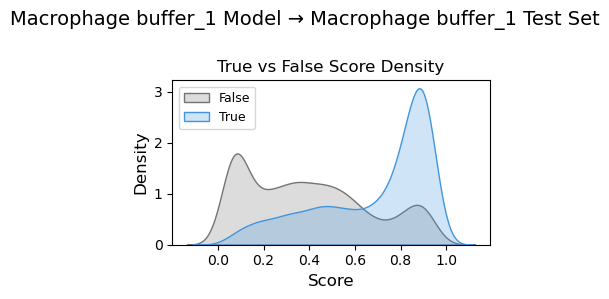

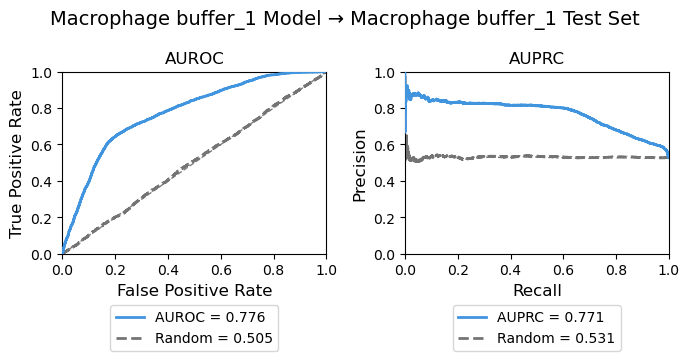

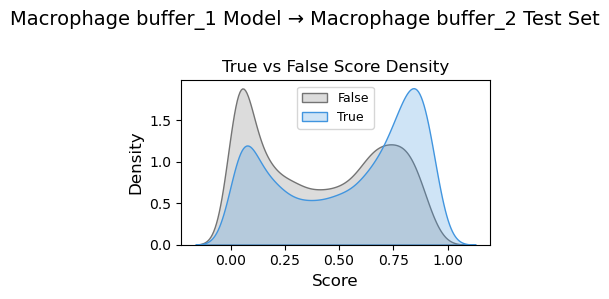

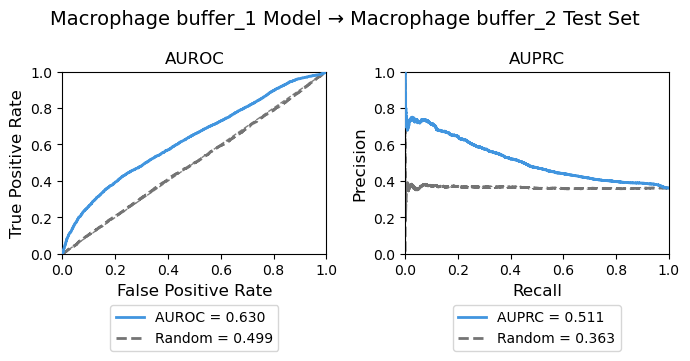

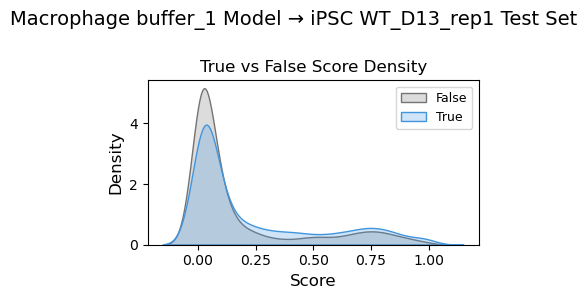

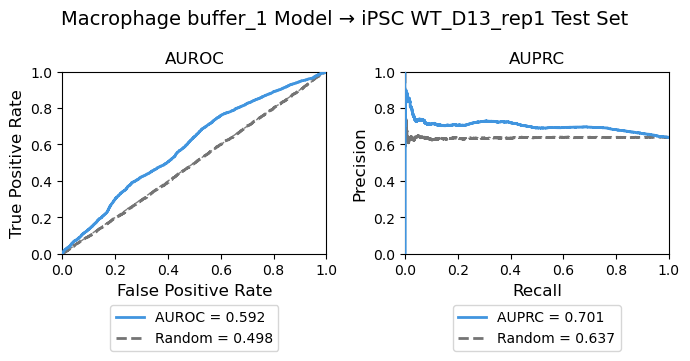

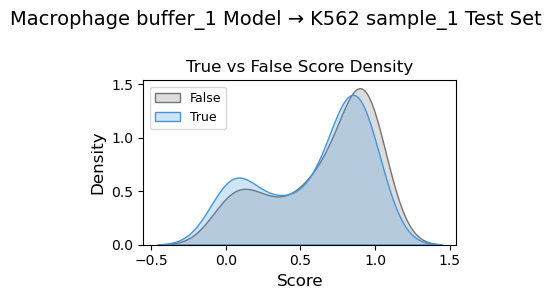

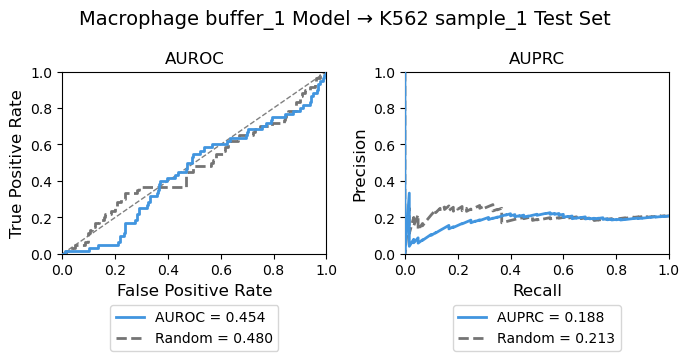

In [14]:
all_comparison_df_list = []

evaluations = [
    # ("mESC", "E7.5_rep1", "mESC", "E7.5_rep1"),
    # ("mESC", "E8.5_rep1", "mESC", "E8.5_rep1"),
    # ("iPSC", "WT_D13_rep1", "iPSC", "WT_D13_rep1"),
    ("Macrophage", "buffer_1", "Macrophage", "buffer_1"), # self evaluation
    ("Macrophage", "buffer_1", "Macrophage", "buffer_2"), # cross sample evaluation
    ("Macrophage", "buffer_1", "iPSC", "WT_D13_rep1"), # cross cell-type evaluation
    ("Macrophage", "buffer_1", "K562", "sample_1"), # cross cell-type evaluation
    # ("K562", "sample_1", "K562", "sample_1")
]

dataset_split_type = "test"
subset_size = 15000

for model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample in evaluations:
    print(f"Model {model_training_sample} | {dataset_split_type.capitalize()} set {evaluation_sample}")
    
    tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][model_training_sample]
    tf_dna_model_chkpt = tf_dna_model_checkpoints[model_cell_type]
    
    if tf_tg_model_chkpt is None:
        logging.warning(f"Skipping evaluation for {model_cell_type} {model_training_sample} → {test_set_cell_type} {evaluation_sample} due to missing TF-TG checkpoint")
        continue


    cell_type_cache_dir = DATA_DIR / f"{test_set_cell_type}_cache"

    # print(f"Loading cached dataset with subset size: {subset_size}")
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
        sample_name=evaluation_sample,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type=dataset_split_type,
        subset_size=subset_size
        )
    
    tf_tg_model = load_tf_tg_regulation_model(
        tf_dna_model_chkpt, 
        tf_tg_model_chkpt, 
        tf_embeddings_tensor, 
        tf_mask_tensor
        )

    # print("Moving model to device")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = tf_tg_model.model
    model = model.to(device)

    criterion = torch.nn.BCEWithLogitsLoss()
    score_threshold = 0.5
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model.eval()

    total_loss = 0.0
    n_edges = 0

    all_scores = []
    all_labels = []

    # print(f"Evaluating on {dataset_split_type} set")
    for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
        # set batch peak_distance values to zero to eliminate distance information from predictions
        batch["peak_distance"] = torch.zeros_like(batch["peak_distance"])
        
        batch = tf_to_tg_module.move_batch_to_device(batch, device)

        labels = batch["label"]
        cell_mask = batch["cell_mask"]
        E, C = cell_mask.shape

        edge_logits, _ = model.forward(
            tf_embedding=batch["tf_embedding"],
            tf_mask=batch["tf_mask"],
            peak_sequences=batch["peak_sequences"],
            peak_accessibility=batch["peak_accessibility"],
            peak_distance=batch["peak_distance"],
            tf_expression=batch["tf_expression"],
            tg_expression=batch["tg_expression"],
            peak_mask=batch.get("peak_mask", None),
            cell_mask=cell_mask,
            pooling_mode=pooling_mode,
            pooling_temperature=pooling_temperature,
        )

        loss = criterion(edge_logits, labels)

        total_loss += loss.item() * E
        n_edges += E

        scores = torch.sigmoid(edge_logits)

        all_scores.append(scores.detach().cpu().numpy().ravel())
        all_labels.append(labels.detach().cpu().numpy().ravel())

    all_scores_flat = np.concatenate(all_scores)
    all_labels_flat = np.concatenate(all_labels)

    metrics = stat_utils.compute_binary_classification_metrics(
        labels=all_labels_flat,
        scores=all_scores_flat,
        score_threshold=score_threshold,
        random_state=42,
    )

    mean_loss = total_loss / max(n_edges, 1)

    metrics["Model"] = model_training_sample
    metrics["Test Set"] = evaluation_sample

    metric_df = pd.DataFrame([metrics])

    col_order = ["Model", "Test Set", "auroc", "auprc", "accuracy", "precision", "recall", "rand_auroc", "rand_auprc"]

    metric_df = metric_df[col_order]

    all_comparison_df_list.append(metric_df)
    
    title = f"{model_cell_type} {model_training_sample} Model → {test_set_cell_type} {evaluation_sample} Test Set"
    
    histogram_fig = plotting_utils.plot_score_histograms(
        labels=all_labels_flat,
        scores=all_scores_flat,
        n_bins=50,
        y_log=False,
        panel_kind="kde",
        density=False,
        title = title
    )
    histogram_fig.show()

    auroc_auprc_fig = plotting_utils.plot_auroc_auprc(
        labels=all_labels_flat,
        scores=all_scores_flat,
        title = title
    )
    auroc_auprc_fig.show()
    
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)
display(full_comparison_df.T)

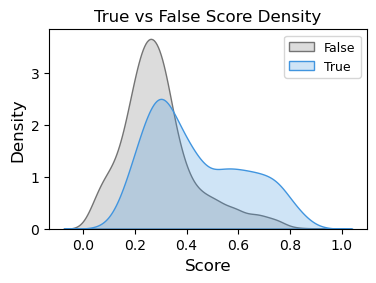

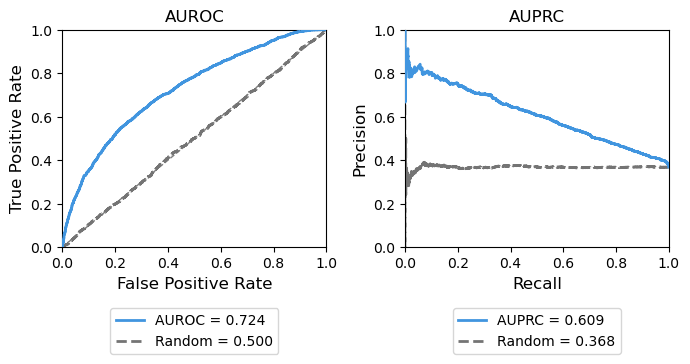

In [56]:
histogram_fig = plotting_utils.plot_score_histograms(
    labels=all_labels_flat,
    scores=all_scores_flat,
    n_bins=50,
    y_log=False,
    panel_kind="kde",
    density=False,
)
histogram_fig.show()

auroc_auprc_fig = plotting_utils.plot_auroc_auprc(
    labels=all_labels_flat,
    scores=all_scores_flat,
)
auroc_auprc_fig.show()

### Evaluate the predictions

In [45]:
importlib.reload(stat_utils)

<module 'stat_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/stat_utils.py'>

In [10]:
metrics = stat_utils.compute_binary_classification_metrics(
    labels=all_labels_flat,
    scores=all_scores_flat,
    score_threshold=score_threshold,
    random_state=42,
)

mean_loss = total_loss / max(n_edges, 1)

metrics["Model"] = model_training_sample
metrics["Test Set"] = evaluation_sample
metrics["loss"] = mean_loss
metrics["score_min"] = float(all_scores_flat.min())
metrics["score_max"] = float(all_scores_flat.max())
metrics["score_mean"] = float(all_scores_flat.mean())
metrics["score_std"] = float(all_scores_flat.std())
metrics["n_pred_pos"] = int((all_scores_flat >= score_threshold).sum())
metrics["n_pred_neg"] = int((all_scores_flat < score_threshold).sum())

metric_df = pd.DataFrame([metrics])

col_order = ["Model", "Test Set", "auroc", "auprc", "accuracy", "precision", "rand_auroc", "rand_auprc"]

metric_df = metric_df[col_order]


all_comparison_df_list.append(metric_df)

print("Final Test Metrics:")
display(metric_df.T)

Final Test Metrics:


,0
Model,E7.5_rep1
Test Set,E7.5_rep1
auroc,0.572233
auprc,0.455054
accuracy,0.6418
precision,0.649682
rand_auroc,0.505406
rand_auprc,0.371783


In [44]:
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)
display(full_comparison_df)

,Model,Test Set,auroc,auprc,accuracy,precision,rand_auroc,rand_auprc
0,E7.5_rep1,E7.5_rep1,0.696399,0.577159,0.6708,0.698347,0.519975,0.381786
1,E7.5_rep1,E8.5_rep1,0.621752,0.629031,0.5656,0.661054,0.501131,0.519073
2,E8.5_rep1,E7.5_rep1,0.636114,0.489747,0.6294,0.493907,0.526398,0.390878
3,E8.5_rep1,E8.5_rep1,0.690027,0.686342,0.6314,0.638061,0.494796,0.520802


## Testing model sizes through the network

In [23]:
evaluation_cell_type = "mESC"
model_training_sample = "E7.5_rep1"
evaluation_sample = "E7.5_rep1"

print(f"Model {model_training_sample} | Test set {evaluation_sample}")

tf_tg_model_chkpt = tf_tg_model_checkpoints[evaluation_cell_type][model_training_sample]
tf_dna_model_chkpt = tf_dna_model_checkpoints[evaluation_cell_type]

# print(f"Loading TF→TG model")
dataset_split_type = "test"
subset_size = 5000

cell_type_cache_dir = DATA_DIR / f"{evaluation_cell_type}_cache"

# print(f"Loading cached dataset with subset size: {subset_size}")
data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
    sample_name=evaluation_sample,
    cell_type_cache_dir=cell_type_cache_dir,
    split_type=dataset_split_type,
    subset_size=subset_size
    )

tf_tg_model = load_tf_tg_regulation_model(tf_dna_model_chkpt, tf_tg_model_chkpt, tf_embeddings_tensor, tf_mask_tensor)

# print("Moving model to device")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = tf_tg_model.model

Model E7.5_rep1 | Test set E7.5_rep1


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [24]:
model

TFTGRegulationModel(
  (tf_peak_model): TFPeakBindingModel(
    (tf_encoder): Sequential(
      (0): Linear(in_features=128, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=128, out_features=128, bias=True)
    )
    (peak_encoder): Sequential(
      (0): Conv1d(4, 64, kernel_size=(15,), stride=(1,), padding=(7,))
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): GELU(approximate='none')
      (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
      (4): Conv1d(64, 128, kernel_size=(9,), stride=(1,), padding=(4,))
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): GELU(approximate='none')
      (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
      (8): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (9): BatchNorm1d(1

In [25]:
def shape_of(x):
    if torch.is_tensor(x):
        return tuple(x.shape)
    if isinstance(x, dict):
        return {k: shape_of(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [shape_of(v) for v in x]
    if x is None:
        return None
    return type(x).__name__


def make_shape_hook(name):
    def hook(module, args, kwargs, output):
        print(f"\n{name}")
        print(f"  args  : {shape_of(args)}")
        print(f"  kwargs: {shape_of(kwargs)}")
        print(f"  output: {shape_of(output)}")
    return hook


model = tf_tg_model.model.to(device)
model.eval()

hook_names = {
    "tf_peak_model.tf_encoder",
    "tf_peak_model.peak_encoder",
    "tf_peak_model.cross_attn",
    "tf_peak_model.classifier",
    "peak_feature_proj",
    "tf_expr_proj",
    "tg_expr_proj",
    "tg_query_proj",
    "peak_attention",
    "norm",
    "classifier",
}

# Clear old hooks aggressively in notebook debugging
for module in model.modules():
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_hooks.clear()

hooks = []
for name, module in model.named_modules():
    if name in hook_names:
        hooks.append(
            module.register_forward_hook(
                make_shape_hook(name),
                with_kwargs=True,
            )
        )
        
batch = next(iter(data_loader))
batch = tf_to_tg_module.move_batch_to_device(batch, device)

print("\nBatch input shapes:")
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"  {k}: {tuple(v.shape)}")

with torch.no_grad():
    edge_logits, aux_outputs = model(
        tf_embedding=batch["tf_embedding"],
        tf_mask=batch["tf_mask"],
        peak_sequences=batch["peak_sequences"],
        peak_accessibility=batch["peak_accessibility"],
        peak_distance=batch["peak_distance"],
        tf_expression=batch["tf_expression"],
        tg_expression=batch["tg_expression"],
        peak_mask=batch.get("peak_mask", None),
        cell_mask=batch["cell_mask"],
        pooling_mode="lse",
        pooling_temperature=1.0,
    )

print("\nFinal outputs:")
print("  edge_logits:", tuple(edge_logits.shape))
print("  aux_outputs:", shape_of(aux_outputs))

for h in hooks:
    h.remove()


Batch input shapes:
  tf_embedding: (64, 5588, 128)
  tf_mask: (64, 5588)
  peak_sequences: (64, 12, 256, 4)
  peak_accessibility: (64, 32, 12)
  peak_distance: (64, 12)
  tf_expression: (64, 32)
  tg_expression: (64, 32)
  label: (64,)
  cell_mask: (64, 32)
  peak_mask: (64, 12)

tf_peak_model.tf_encoder
  args  : [(768, 5588, 128)]
  kwargs: {}
  output: (768, 5588, 128)

tf_peak_model.peak_encoder
  args  : [(768, 4, 256)]
  kwargs: {}
  output: (768, 128, 16)

tf_peak_model.cross_attn
  args  : []
  kwargs: {'x': (768, 5588, 128), 'context': (768, 16, 128), 'mask': (768, 5588), 'context_mask': (768, 16)}
  output: [(768, 5588, 128), (768, 16, 128)]

tf_peak_model.classifier
  args  : [(768, 256)]
  kwargs: {}
  output: (768, 1)

peak_feature_proj
  args  : [(2048, 12, 4)]
  kwargs: {}
  output: (2048, 12, 128)

tf_expr_proj
  args  : [(2048, 1)]
  kwargs: {}
  output: (2048, 128)

tg_expr_proj
  args  : [(2048, 1)]
  kwargs: {}
  output: (2048, 128)

tg_query_proj
  args  : [(2048

## Test model performance vs other inference methods

In [144]:
model_cell_type = "K562"
evaluation_sample = "sample_1"

### Load the cached test dataset to get the labels and gene name to index maps

In [166]:
cell_type_cache_dir = DATA_DIR / f"{model_cell_type}_cache"

# Load the cached test dataset
subset_size = 5000
split_type = "val"
data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
    sample_name=evaluation_sample,
    cell_type_cache_dir=cell_type_cache_dir,
    split_type=split_type,
    subset_size=subset_size
    )

# Create the TF and TG index to name mappings
tftg_inputs_test = torch.load(
    cell_type_cache_dir / "tf_tg_training_cache" / evaluation_sample / f"tftg_inputs_{split_type}.pt",
    weights_only=False,
)
test_set_tf_indices = list(tftg_inputs_test['tf_idx'].numpy())
test_set_tg_indices = list(tftg_inputs_test['tg_idx'].numpy())

tf_idx_to_name = {idx: name for name, idx in metadata["tf_name_to_idx"].items()}
tg_idx_to_name = {idx: name for name, idx in metadata["tg_id_to_idx"].items()}

test_set_tf_names = [tf_idx_to_name[idx] for idx in set(test_set_tf_indices)]
test_set_tg_names = [tg_idx_to_name[idx] for idx in set(test_set_tg_indices)]

test_set_tf_names_upper = [name.upper() for name in test_set_tf_names]
test_set_tg_names_upper = [name.upper() for name in test_set_tg_names]
print(f"Test set TFs: {test_set_tf_names[:5]}")
print(f"Test set TGs: {test_set_tg_names[:5]}")

Test set TFs: ['CTCF', 'FOXO4', 'GATA2', 'MITF', 'NR2C1']
Test set TGs: ['NDUFA7', 'ZNF829', 'TUBB8B', 'IL9RP4', 'ROCK1P1']


### Load the TF-TG model and run model predictions on the labeled test set

In [172]:

tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][evaluation_sample]
tf_dna_model_chkpt = tf_dna_model_checkpoints[model_cell_type]

logging.info(f"TF-DNA model checkpoint: {tf_dna_model_chkpt.name}")
logging.info(f"TF-TG model checkpoint: {tf_tg_model_chkpt.name}")

# Load the TF→TG model
tf_tg_model = load_tf_tg_regulation_model(
    tf_dna_model_chkpt, 
    tf_tg_model_chkpt, 
    tf_embeddings_tensor, 
    tf_mask_tensor
    )

# Generate the model predictions for the test set and create a DataFrame with TF names, TG names, and predicted scores
def generate_model_predictions(model, data_loader, device, tf_idx_to_name, tg_idx_to_name):
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model = model.to(device)
    model.eval()

    tf_indices_list = []
    tg_indices_list = []
    all_scores = []

    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
            tf_indices = batch["tf_idx"].detach().cpu().numpy().ravel()
            tg_indices = batch["tg_idx"].detach().cpu().numpy().ravel()

            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            edge_logits, _ = model.forward(
                tf_embedding=batch["tf_embedding"],
                tf_mask=batch["tf_mask"],
                peak_sequences=batch["peak_sequences"],
                peak_accessibility=batch["peak_accessibility"],
                peak_distance=batch["peak_distance"],
                tf_expression=batch["tf_expression"],
                tg_expression=batch["tg_expression"],
                peak_mask=batch.get("peak_mask", None),
                cell_mask=batch["cell_mask"],
                pooling_mode=pooling_mode,
                pooling_temperature=pooling_temperature,
            )

            scores = torch.sigmoid(edge_logits)

            tf_indices_list.append(tf_indices)
            tg_indices_list.append(tg_indices)
            all_scores.append(scores.detach().cpu().numpy().ravel())

    all_tf_indices_flat = np.concatenate(tf_indices_list)
    all_tg_indices_flat = np.concatenate(tg_indices_list)
    all_scores_flat = np.concatenate(all_scores)

    tf_names = [tf_idx_to_name[int(idx)].upper() for idx in all_tf_indices_flat]
    tg_names = [tg_idx_to_name[int(idx)].upper() for idx in all_tg_indices_flat]

    prediction_df = pd.DataFrame({
        "Source": tf_names,
        "Target": tg_names,
        "Score": all_scores_flat,
    })

    prediction_df = (
        prediction_df.groupby(["Source", "Target"], as_index=False)["Score"]
        .median()
    )

    return prediction_df

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
prediction_df = generate_model_predictions(tf_tg_model.model, data_loader, device, tf_idx_to_name, tg_idx_to_name)
print(prediction_df.head())

INFO - TF-DNA model checkpoint: epoch=13-val_auroc=0.9566-val_loss=0.2042.ckpt
INFO - TF-TG model checkpoint: epoch=05-val_auroc=0.7456-val_loss=0.5752.ckpt
/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you d

  Source  Target     Score
0   ADNP  AKT1S1  0.520119
1   ADNP   BRME1  0.484168
2   ADNP  CAPN12  0.575007
3   ADNP   FCGRT  0.296248
4   ADNP  GAPDHS  0.204194


### Create the ground truth dataframe from the labeled test set

In [167]:
# Create the TF-TG label DataFrame
tftg_inputs_test.keys()
test_tf_input = tftg_inputs_test["tf_name"]
test_tg_input = tftg_inputs_test["tg_name"]
test_labels = tftg_inputs_test["label"]

# create TF-TG label DataFrame
tf_tg_label_df = pd.DataFrame({
    "Source": test_tf_input,
    "Target": test_tg_input,
    "Label": test_labels,
})

tf_tg_label_df = tf_tg_label_df.drop_duplicates(["Source", "Target"])

print(tf_tg_label_df["Label"].value_counts())
positives = tf_tg_label_df["Label"].sum()
negatives = len(tf_tg_label_df) - positives
print(f"Positives: {positives}, Negatives: {negatives}, Ratio: {positives / max(negatives, 1):.4f}")

gt_df: pd.DataFrame = tf_tg_label_df[tf_tg_label_df["Label"] == 1] 
gt_tfs = set(gt_df["Source"].str.upper().unique()) 
gt_targets = set(gt_df["Target"].str.upper().unique()) 
gt_pairs = set(gt_df["Source"].str.upper() + "\t" + gt_df["Target"].str.upper())

Label
0.0    44521
1.0    28074
Name: count, dtype: int64
Positives: 28074.0, Negatives: 44521.0, Ratio: 0.6306


### Load the inferred GRNs for the other inference methods

In [175]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score
)

def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.upper()
    df["Target"] = df["Target"].astype(str).str.upper()

    return df

OTHER_METHOD_MUON_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns")

other_method_grns = {}
logging.info(f"\nProcessing sample: {evaluation_sample} | Dataset: {model_cell_type}")

linger_path       = OTHER_METHOD_MUON_DIR / "LINGER_muon" / f"linger_{model_cell_type}_{evaluation_sample}.tsv"
scenic_plus_path  = OTHER_METHOD_MUON_DIR / "SCENIC_muon" / f"scenicplus_{model_cell_type}_{evaluation_sample}.tsv"
cell_oracle_path  = OTHER_METHOD_MUON_DIR / "CellOracle_muon" / f"celloracle_{model_cell_type}_{evaluation_sample}.tsv"
pando_path        = OTHER_METHOD_MUON_DIR / "Pando_muon" / f"pando_{model_cell_type}_{evaluation_sample}.tsv"
figr_path         = OTHER_METHOD_MUON_DIR / "FigR_muon" / f"figr_{model_cell_type}_{evaluation_sample}.tsv"

method_info = {
    "SCENIC+":    {"path": scenic_plus_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "LINGER":     {"path": linger_path,      "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "CellOracle": {"path": cell_oracle_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "Pando":      {"path": pando_path,       "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    "FigR":       {"path": figr_path,        "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
}
        
standardized_method_dfs = {}
for method_name, info in method_info.items():
    logging.info(f"  - Loading {method_name}")
    df_std = load_and_standardize_method(method_name, info)
    
    df_std = df_std[df_std["Source"].isin(test_set_tf_names_upper)].copy()
    
    mask = df_std["Source"].isin(gt_tfs) & df_std["Target"].isin(gt_targets)
    
    df_filtered = df_std.loc[mask]
    
    standardized_method_dfs[method_name] = df_std

INFO - 
Processing sample: sample_1 | Dataset: K562
INFO -   - Loading SCENIC+
INFO -   - Loading LINGER
INFO -   - Loading CellOracle
INFO -   - Loading Pando
INFO -   - Loading FigR


### Calculate the performance metrics for each inferred GRN

In [177]:
def compute_metrics(name: str, df: pd.DataFrame, gt_pairs: set, score_threshold: float):    
    logging.info(f"    - After filtering to test set TFs, {len(df)} edges remain")
        
    labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
    scores = df["Score"].tolist()
    
    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    preds = (scores >= score_threshold).astype(int)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)

    if len(np.unique(labels)) < 2:
        auroc = np.nan
        auprc = np.nan
        rand_auroc = np.nan
        rand_auprc = np.nan
    else:
        auroc = roc_auc_score(labels, scores)
        auprc = average_precision_score(labels, scores)

        rng = np.random.default_rng(42)
        rand_scores = rng.permutation(scores)

        rand_auroc = roc_auc_score(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)

    return pd.DataFrame([{
        "method_name": name,
        "auroc": auroc,
        "auprc": auprc,
        "rand_auroc": rand_auroc,
        "rand_auprc": rand_auprc,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "n_edges": len(labels),
        "n_pos": int(labels.sum()),
        "n_neg": int((labels == 0).sum()),
        "score_threshold": score_threshold,
    }])

# Add the TF-TG model predictions to the standardized_method_dfs for metric computation
standardized_method_dfs["TF-TG Model"] = prediction_df

inference_method_dfs = []
for method_name, df_std in standardized_method_dfs.items():
    logging.info(f"Computing metrics for {method_name}")
    df_metrics = compute_metrics(method_name, df_std, gt_pairs, score_threshold=0.5)
    df_metrics["Model"] = method_name
    df_metrics["Test Set"] = evaluation_sample
    inference_method_dfs.append(df_metrics)
    
inference_comparison_df = pd.concat(inference_method_dfs, ignore_index=True)
display(inference_comparison_df.T)

INFO - Computing metrics for SCENIC+
INFO -     - After filtering to test set TFs, 42910 edges remain
INFO - Computing metrics for LINGER
INFO -     - After filtering to test set TFs, 2629880 edges remain
INFO - Computing metrics for CellOracle
INFO -     - After filtering to test set TFs, 538814 edges remain
INFO - Computing metrics for Pando
INFO -     - After filtering to test set TFs, 43199 edges remain
INFO - Computing metrics for FigR
INFO -     - After filtering to test set TFs, 888389 edges remain
INFO - Computing metrics for TF-TG Model
INFO -     - After filtering to test set TFs, 5000 edges remain


,0,1,2,3,4,5
method_name,SCENIC+,LINGER,CellOracle,Pando,FigR,TF-TG Model
auroc,0.533091,0.596089,0.460239,0.463634,0.489349,0.747859
auprc,0.003555,0.006611,0.005978,0.006321,0.004637,0.642257
rand_auroc,0.526315,0.49766,0.505207,0.500186,0.503502,0.500988
rand_auprc,0.003877,0.005252,0.006997,0.006515,0.004791,0.399945
accuracy,0.996644,0.636281,0.993126,0.754855,0.970728,0.693
precision,0.0,0.00692,0.0,0.006041,0.00472,0.616693
recall,0.0,0.478862,0.0,0.219512,0.024886,0.587639
n_edges,42910,2629880,538814,43199,888389,5000
n_pos,144,13814,3704,287,4179,1974


In [178]:
display(inference_comparison_df.set_index("method_name").sort_values("auroc", ascending=False))

,auroc,auprc,rand_auroc,rand_auprc,accuracy,precision,recall,n_edges,n_pos,n_neg,score_threshold,Model,Test Set
method_name,,,,,,,,,,,,,
TF-TG Model,0.747859,0.642257,0.500988,0.399945,0.693000,0.616693,0.587639,5000,1974,3026,0.5,TF-TG Model,sample_1
LINGER,0.596089,0.006611,0.497660,0.005252,0.636281,0.006920,0.478862,2629880,13814,2616066,0.5,LINGER,sample_1
SCENIC+,0.533091,0.003555,0.526315,0.003877,0.996644,0.000000,0.000000,42910,144,42766,0.5,SCENIC+,sample_1
FigR,0.489349,0.004637,0.503502,0.004791,0.970728,0.004720,0.024886,888389,4179,884210,0.5,FigR,sample_1
Pando,0.463634,0.006321,0.500186,0.006515,0.754855,0.006041,0.219512,43199,287,42912,0.5,Pando,sample_1
CellOracle,0.460239,0.005978,0.505207,0.006997,0.993126,0.000000,0.000000,538814,3704,535110,0.5,CellOracle,sample_1


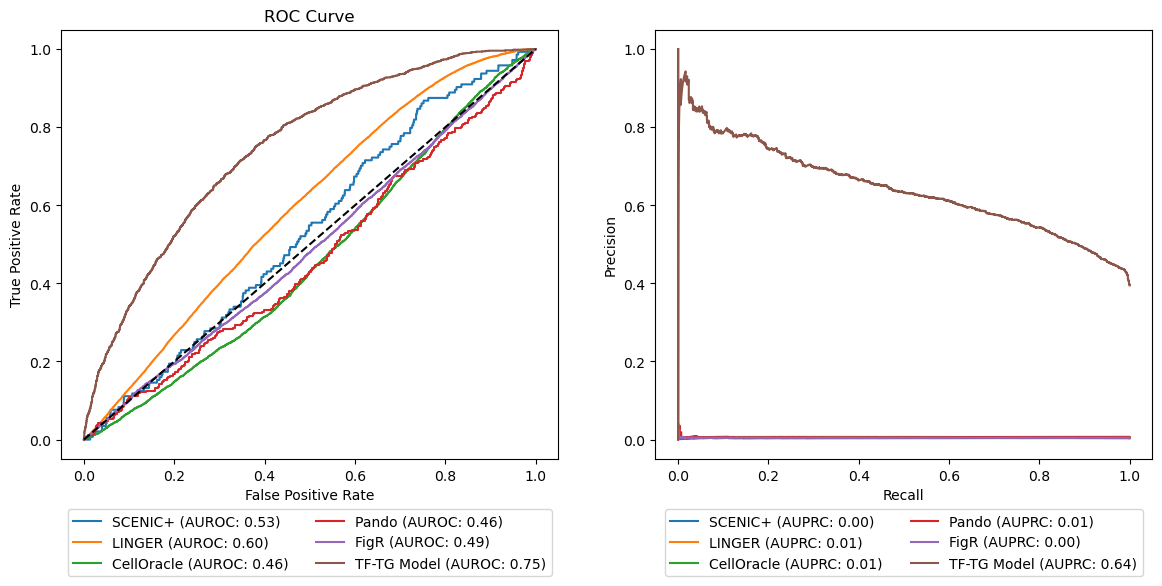

In [179]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

def plot_roc_pr_curves(method_dict: dict[str, pd.DataFrame], gt_pairs: set):
    plt.figure(figsize=(12, 6))
    
    rng = np.random.default_rng(42)

    plt.subplot(1, 2, 1)
    for method_name, df in method_dict.items():
        labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
        scores = df["Score"].tolist()
        
        auroc = roc_auc_score(labels, scores)
        fpr, tpr, _ = roc_curve(labels, scores)
        rand_scores = rng.uniform(np.array(scores).min(), np.array(scores).max(), size=len(scores))
        rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)
        
        plt.plot(fpr, tpr, label=f"{method_name} (AUROC: {auroc:.2f})")
        # plt.plot(rand_fpr, rand_tpr, "k--", label="Random")
    
    plt.plot([0, 1], [0, 1], "k--", label="")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncols=2)


    plt.subplot(1, 2, 2)
    for method_name, df in method_dict.items():
        labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
        scores = df["Score"].tolist()
        
        auprc = average_precision_score(labels, scores)
        precision, recall, _ = precision_recall_curve(labels, scores)
        plt.plot(recall, precision, label=f"{method_name} (AUPRC: {auprc:.2f})")
        
        rand_scores = rng.uniform(np.array(scores).min(), np.array(scores).max(), size=len(scores))
        rand_precision, rand_recall, _ = precision_recall_curve(labels, rand_scores)
        # plt.plot(rand_recall, rand_precision, "k--", label="")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncols=2)

    plt.tight_layout()
    plt.show()

plot_roc_pr_curves(standardized_method_dfs, gt_pairs)